In [ ]:
from google.colab import files

uploaded = files.upload()

Saving q3_retail_promotions.csv to q3_retail_promotions.csv


In [ ]:
import os
os.listdir()

['.config',
 'q2_customers.csv',
 'q3_retail_promotions.csv',
 'q1_heart_disease.csv',
 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("q1_heart_disease.csv")
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [ ]:
# Shape
print("Shape:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


### Data Inspection

- The dataset shape shows number of rows and columns.
- Data types help identify numerical and categorical features.
- Missing values check ensures data quality before preprocessing.

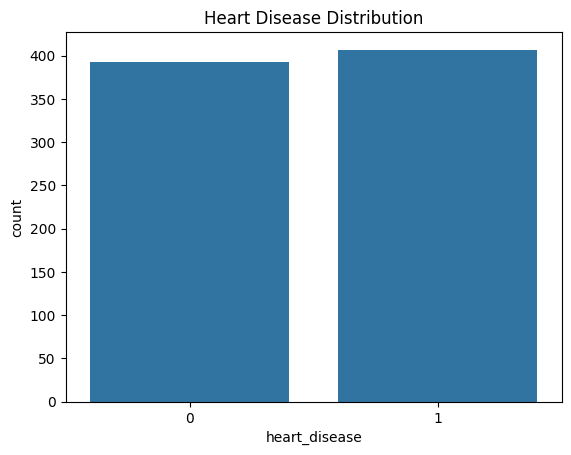

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='heart_disease', data=df)
plt.title("Heart Disease Distribution")
plt.show()

This plot shows the distribution of patients with and without heart disease.

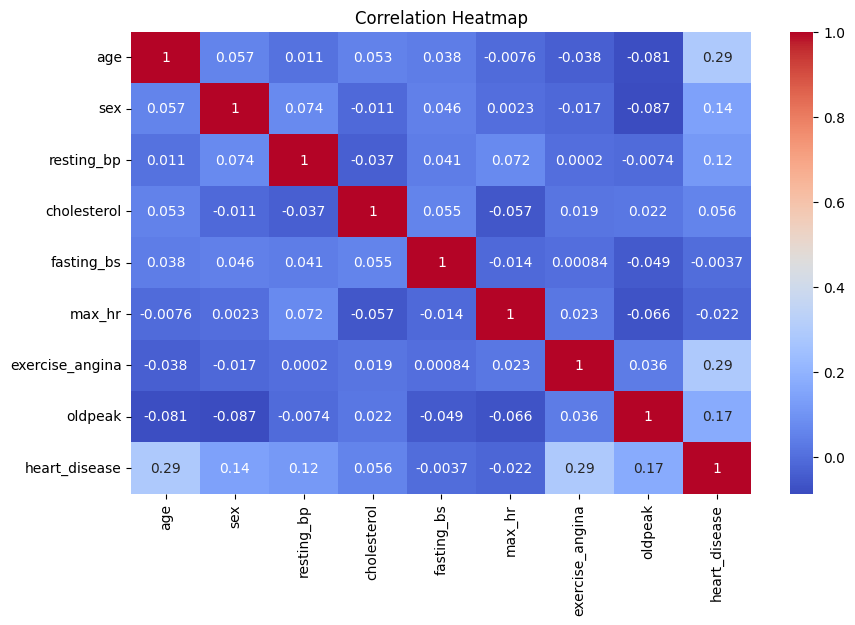

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows relationships between numerical variables.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


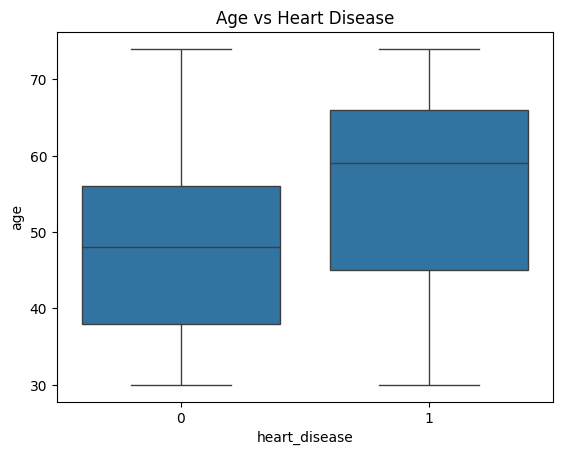

In [ ]:
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

This shows how age varies between patients with and without heart disease

In [ ]:
df = df.fillna(df.median(numeric_only=True))

Missing values are handled using median imputation as it is robust to outliers.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

Categorical variables are converted into numerical format using one-hot encoding.

In [ ]:
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Data is split into training and testing sets using stratification to maintain class balance.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature scaling is applied using StandardScaler to normalize numerical features.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

Three models are trained: Decision Tree, Random Forest, and Gradient Boosting to compare performance.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    print("\n", name)

    y_pred = model.predict(X_test)

    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


 Decision Tree
Confusion Matrix:
 [[57 22]
 [25 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


 Random Forest
Confusion Matrix:
 [[61 18]
 [15 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


 Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79

Model performance is evaluated using confusion matrix, precision, recall, and F1-score.
The model with the best balance of precision and recall is selected as the best model.

Random Forest performed the best based on a higher F1-score and better balance between precision and recall compared to Decision Tree and Gradient Boosting.

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=3
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


Hyperparameter tuning is performed using GridSearchCV to improve model performance.